# Retrieval Coverage: Score 1 vs Score 2
Analysis of embedding retriever performance on **Score 1** (indirect citations) vs **Score 2** (direct citations).

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyrootutils import setup_root

In [2]:
from patent_retrieval import utils

In [3]:
os.environ["HTTP_PROXY"] = "http://rb-proxy-sl.bosch.com:8080"
os.environ["HTTPS_PROXY"] = "http://rb-proxy-sl.bosch.com:8080"
os.environ["NO_PROXY"] = "localhost,127.0.0.1,.bosch.com"
root = setup_root(".")

## Configuration & Data Loading

In [ ]:
CLEF_IP = Path(os.environ["CLEF_IP_LOCATION"])

test_topics_path = CLEF_IP / "02_topics" / "test-pac" / "relass_clef-ip-2011-PAC_abs.txt"
candidates_path = "/home/alm3rng/patent-retrieval/embeddings/runs/patQwen3-emb-4b-v2_db-v4_all-topics_abstract-claims_aysm_top1000/results.csv"

In [8]:
topics_df = pd.read_csv(
    test_topics_path
            , sep="\t", header=None, skiprows=1, names=["q_id", "doc_id", "score"]
        )
topics_df

,q_id,doc_id,score
0,EP-1221372-A2,EP-0271257,1
1,EP-1221372-A2,EP-0445916,1
2,EP-1221372-A2,EP-0512799,1
3,EP-1221372-A2,EP-0547921,1
4,EP-1221372-A2,EP-0571093,1
...,...,...,...
19556,EP-1936237-A1,EP-0252423,2
19557,EP-1936237-A1,EP-0320621,1
19558,EP-1936750-A1,EP-0948090,2
19559,EP-1936750-A1,EP-0948092,2


In [19]:
candidates_df = pd.read_csv(
    candidates_path
            , sep=",", header=None, skiprows=1, names=["q_id", "doc_id", "score"]
        )


In [20]:
k=100
merged_df = pd.merge(

    topics_df,
    candidates_df.groupby(["q_id"]).apply(lambda x: x.sort_values('score', ascending=False).head(k)).reset_index(drop=True),
    how="left",
    on=["q_id", "doc_id"],
    suffixes=( "_topic","_candidate" ),
)
merged_df["score_candidate"] = merged_df["score_candidate"].fillna(0.0)

/tmp/ipykernel_4018896/3042527668.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  candidates_df.groupby(["q_id"]).apply(lambda x: x.sort_values('score', ascending=False).head(k)).reset_index(drop=True),


## Retrieval Coverage: Score 1 vs Score 2

Distribution of candidates by score_topic:
score_topic
1    56.52
2    43.48
Name: count, dtype: float64


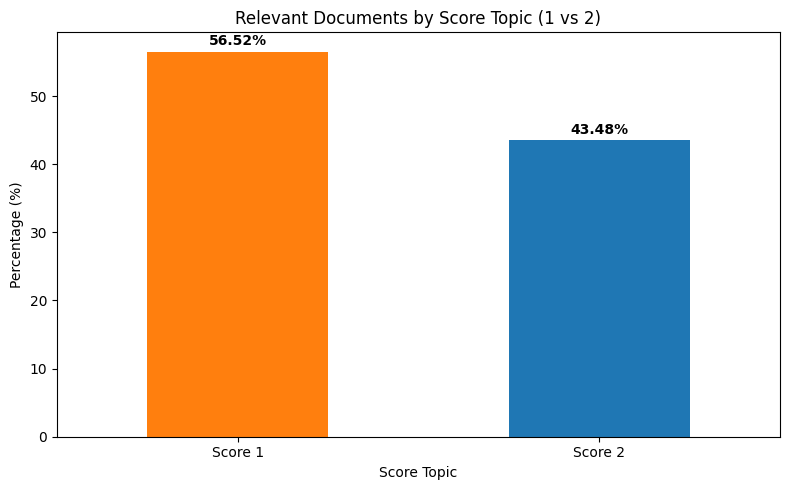

In [21]:
# Distribution of relevance scores in ground truth
score_distribution = merged_df["score_topic"].value_counts()
score_percentages = (score_distribution / len(merged_df) * 100).round(2)
print("Distribution of candidates by score_topic:")
print(score_percentages)

fig, ax = plt.subplots(figsize=(8, 5))
score_percentages.plot(kind="bar", ax=ax, color=["#ff7f0e", "#1f77b4"])
ax.set_title("Relevant Documents by Score Topic (1 vs 2)")
ax.set_xlabel("Score Topic")
ax.set_ylabel("Percentage (%)")
ax.set_xticklabels(["Score 1", "Score 2"], rotation=0)
for i, v in enumerate(score_percentages):
    ax.text(i, v + 1, f"{v}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

Missed candidates (score_candidate=0) by score_topic:
score_topic
1    52.18
2    40.76
dtype: float64


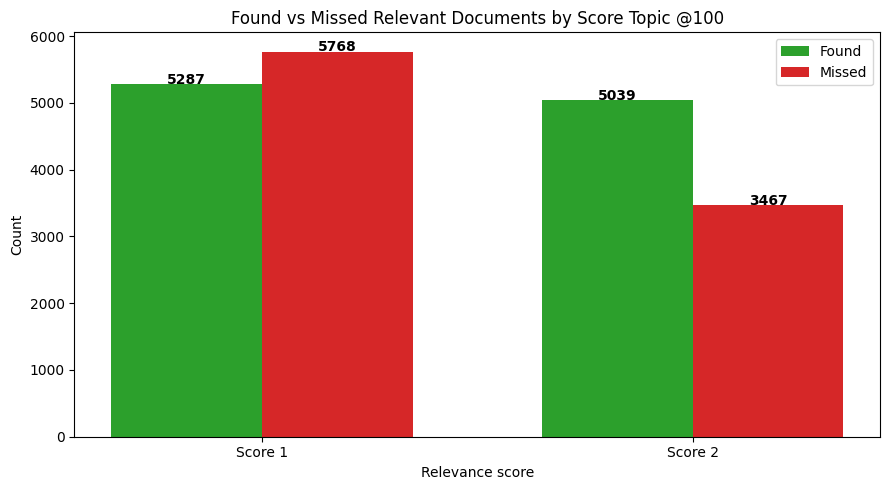

In [23]:
# Found vs Missed relevant documents by score topic
missed_by_score = merged_df[merged_df["score_candidate"] == 0].groupby("score_topic").size()
total_by_score = merged_df.groupby("score_topic").size()
missed_pct = (missed_by_score / total_by_score * 100).round(2)
print("Missed candidates (score_candidate=0) by score_topic:")
print(missed_pct)

found = (total_by_score - missed_by_score).values
missed = missed_by_score.values
labels = ["Score 1", "Score 2"]
x_pos = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x_pos - width / 2, found, width, label="Found", color="#2ca02c")
ax.bar(x_pos + width / 2, missed, width, label="Missed", color="#d62728")
ax.set_xlabel("Relevance score")
ax.set_ylabel("Count")
ax.set_title(f"Found vs Missed Relevant Documents by Score Topic @{k}")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.legend()
for i, (f, m) in enumerate(zip(found, missed)):
    ax.text(i - width / 2, f + 2, str(f), ha="center", fontweight="bold")
    ax.text(i + width / 2, m + 2, str(m), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_4018896/3751164584.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(cutoff, "score"))
/tmp/ipykernel_4018896/3751164584.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(cutoff, "score"))
/tmp/ipykernel_4018896/3751164584.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a fut

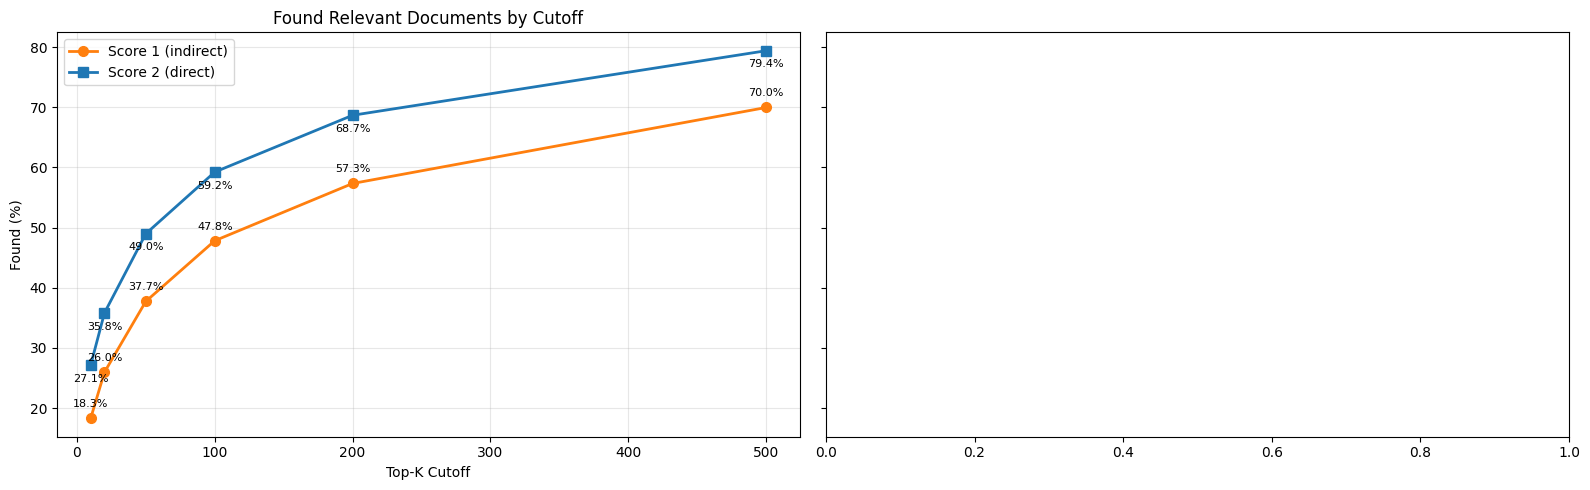

In [24]:
# Recall at different cutoffs, broken down by relevance score
cutoffs = [10, 20, 50, 100, 200, 500]
total_score1 = len(topics_df[topics_df["score"] == 1])
total_score2 = len(topics_df[topics_df["score"] == 2])

found_pct = {1: [], 2: []}
for cutoff in cutoffs:
    top_k = (
        candidates_df.groupby("q_id")
        .apply(lambda x: x.nlargest(cutoff, "score"))
        .reset_index(drop=True)
    )
    merged = pd.merge(
        topics_df, top_k, how="left", on=["q_id", "doc_id"],
        suffixes=("_topic", "_candidate"),
    )
    merged["score_candidate"] = merged["score_candidate"].fillna(0.0)
    found = merged[merged["score_candidate"] > 0]
    found_pct[1].append(len(found[found["score_topic"] == 1]) / total_score1 * 100)
    found_pct[2].append(len(found[found["score_topic"] == 2]) / total_score2 * 100)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

axes[0].plot(cutoffs, found_pct[1], "o-", lw=2, ms=7, label="Score 1 (indirect)", color="#ff7f0e")
axes[0].plot(cutoffs, found_pct[2], "s-", lw=2, ms=7, label="Score 2 (direct)", color="#1f77b4")
axes[0].set(xlabel="Top-K Cutoff", ylabel="Found (%)", title="Found Relevant Documents by Cutoff")
axes[0].legend()
axes[0].grid(alpha=0.3)

"""missed_pct = {s: [100 - v for v in found_pct[s]] for s in [1, 2]}
axes[1].plot(cutoffs, missed_pct[1], "o-", lw=2, ms=7, label="Score 1 (indirect)", color="#ff7f0e")
axes[1].plot(cutoffs, missed_pct[2], "s-", lw=2, ms=7, label="Score 2 (direct)", color="#1f77b4")
axes[1].set(xlabel="Top-K Cutoff", ylabel="Missed (%)", title="Missed Relevant Documents by Cutoff")
axes[1].legend()
axes[1].grid(alpha=0.3)"""

for ax_idx, data in enumerate([found_pct]):
    for cutoff, v1, v2 in zip(cutoffs, data[1], data[2]):
        axes[ax_idx].annotate(f"{v1:.1f}%", (cutoff, v1), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
        axes[ax_idx].annotate(f"{v2:.1f}%", (cutoff, v2), textcoords="offset points", xytext=(0, -12), ha="center", fontsize=8)

plt.tight_layout()
plt.show()